# Irish Wind Speed Analysis Using Historic Met Éireann Weather Data

In [820]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Project dataset
In this project, I analyse wind speed data from across Ireland. To represent different regional conditions, data from the following weather stations has been selected:

- Malin Head (county Donegal) – north-west coastline
- Mace Head (county Galway) - Atlantic west coast 
- Dublin Airport (Dublin) - east coast

Historical wind speed data was obtained from [Met Éireann](https://www.met.ie/climate/available-data/historical-data). The data was downloaded locally and stored in the `data` folder within this project. Each folder contains the CSV file used for analysis, along with additional documentation and licence files, which are retained for reference and data governance purposes.

## Validate data repository structure

To load the datasets, the `pd.read_csv()` function requires the correct file paths. Before loading any data, the project directory is checked to confirm that the expected folders and CSV files are present.

A dictionary is created to store the data directory paths for each weather station, where the keys represent the station names and the values represent the corresponding folder locations. The contents of each directory are then printed using the `for loop` to verify that the required files are available. Iterating through the dictionary approach is adapted from the following [Real Python](https://realpython.com/iterate-through-dictionary-python/) tutorial.


In [821]:
# Create a dictionary to hold weather station data folders
data_dirs = {
    "Malin Head": "../project/data/malin_head/",
    "Mace Head": "../project/data/mace_head/",
    "Dublin Airport": "../project/data/dublin_airport/"
}

# List contents of each data directory using for loop
for station, path in data_dirs.items():
    print(f"\nContents of {station} directory:")
    !ls "{path}"


Contents of Malin Head directory:
Data_Licence.pdf Data_Licence.txt KeyHourly.txt    hly1575.csv


python(38650) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Contents of Mace Head directory:
Data_Licence.pdf Data_Licence.txt KeyHourly.txt    hly275.csv


python(38651) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Contents of Dublin Airport directory:
Data_Licence.pdf Data_Licence.txt KeyHourly.txt    hly532.csv


python(38652) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


## Function for loading and normilizing data

Since multiple datasets are used in this project, a function is created to handle data loading in a consistent way.

Based on manual inspection of the CSV files, the function needs to account for the following:

- Each CSV file contains introductory metadata rows before the actual data begins, which should be skipped.  
  - Malin Head and Dublin Airport require skipping the first 23 rows  
  - Mace Head requires skipping the first 17 rows
- All datasets contain a common **"Date"** column. This column will be converted to datetime format and set as the DataFrame index to support time-based analysis.

Additionally, wind speed variable `wdsp` is the main focus of this analysis. To ensure reliably in further calculations, it is converted to numeric format. Any non-numeric or missing values are automatically converted to `NaN`.

In [822]:
def load_data(file_path, skiprows):
    """Load hourly weather data from a CSV file into a pandas DataFrame."""

    # Read the CSV file into a DataFrame using low_memory=False to avoid dtype warning
    df = pd.read_csv(file_path, skiprows=skiprows, low_memory=False)

    # Convert 'date' column to datetime 
    # format='mixed' handles different date formats - used to avoid pandas warning
    df['date']= pd.to_datetime(df['date'], format='mixed')
    
    # Convert wind speed to numeric (invalid values become NaN)
    df['wdsp'] = pd.to_numeric(df['wdsp'], errors='coerce')
    
    # Set 'date' column as index
    df = df.set_index('date')
    
    return df

## Load Malin Head dataset

In [823]:
# Define file path for Malin Head data
malin_data_dir = "../project/data/malin_head/"
malin_filename = "hly1575.csv"
malin_path = malin_data_dir + malin_filename

# Load Malin Head data (skip first 23 rows)
malin_df = load_data(malin_path, skiprows=23)

# Show first 5 rows
malin_df.head(5)

,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,msl,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
date,,,,,,,,,,,,,,,,,,,,
1955-05-01 01:00:00,0,0.0,0,8.5,0,7.2,5.5,9.1,83,1005.6,0,11.0,0,130,3,2,0.0,30000,40,7
1955-05-01 02:00:00,0,0.0,0,8.2,0,7.2,6.1,9.3,85,1004.4,0,11.0,0,120,1,2,0.0,30000,100,6
1955-05-01 03:00:00,3,0.0,0,7.3,0,6.6,5.5,9.3,91,1003.8,0,8.0,0,120,1,2,0.0,30000,220,5
1955-05-01 04:00:00,3,0.0,0,7.8,0,7.2,6.1,9.6,91,1002.7,0,18.0,0,130,3,2,0.0,30000,90,7
1955-05-01 05:00:00,0,0.0,0,8.1,0,7.3,6.6,9.7,89,1002.1,0,9.0,0,110,2,2,0.0,40000,90,7


## Load Mace Head dataset

In [824]:
# Define file path for Mace Head data
mace_data_dir = "../project/data/mace_head/"
mace_filename = "hly275.csv"
mace_path = mace_data_dir + mace_filename

# Load Mace Head data (skip first 17 rows)
mace_df = load_data(mace_path, skiprows=17)

# Show first 5 rows
mace_df.head(5)

,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,msl,ind.3,wdsp,ind.4,wddir
date,,,,,,,,,,,,,,
2003-08-13 01:00:00,-1,,4,,4,,,,,,7,NaN,7,
2003-08-13 02:00:00,-1,,4,,4,,,,,,7,NaN,7,
2003-08-13 03:00:00,-1,,4,,4,,,,,,7,NaN,7,
2003-08-13 04:00:00,-1,,4,,4,,,,,,7,NaN,7,
2003-08-13 05:00:00,-1,,4,,4,,,,,,7,NaN,7,


## Load Dublin Airport dataset

In [825]:
# Define file path for Dublin Airport data
dublin_data_dir = "../project/data/dublin_airport/"
dublin_filename = "hly532.csv"
dublin_path = dublin_data_dir + dublin_filename

# Load Dublin Airport data (skip first 23 rows)
dublin_df = load_data(dublin_path, skiprows=23)

# Show first 5 rows
dublin_df.head(5)

,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,msl,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
date,,,,,,,,,,,,,,,,,,,,
1945-01-01 00:00:00,2,0.0,0,4.9,0,4.6,4.4,8.2,95,1035.8,1,0,1,0,50,4,0.0,200,2,8
1945-01-01 01:00:00,3,0.0,0,5.1,0,4.9,4.4,8.5,97,1035.8,1,0,1,0,45,4,0.0,200,2,8
1945-01-01 02:00:00,2,0.0,0,5.1,0,4.8,4.4,8.5,97,1035.8,1,0,1,0,50,4,0.0,4800,4,8
1945-01-01 03:00:00,0,0.2,0,5.2,0,5.0,4.4,8.5,97,1036.1,1,0,1,0,50,4,0.0,6000,4,8
1945-01-01 04:00:00,2,0.0,0,5.6,0,5.4,5.0,8.8,97,1036.2,1,7,1,250,50,5,0.0,6000,4,8


## Missing values in wind speed data
Since most of the subsequent analysis performed on the wind speed, the `wdsp` column is checked for missing values. The percentage of missing observations is calculated for each dataset using a method adapted from the following [Stack Overflow](https://stackoverflow.com/questions/51070985/find-out-the-percentage-of-missing-values-in-each-column-in-the-given-dataset) discussion.

In [870]:
missing_pct = malin_df["wdsp"].isna().sum() * 100 / len(malin_df)

print(f"Malin dataet - missing wind speed values: {missing_pct:.2f}%")

Malin dataet - missing wind speed values: 0.01%


In [872]:
missing_pct = mace_df["wdsp"].isna().sum() * 100 / len(mace_df)

print(f"Mace dataset - missing wind speed values: {missing_pct:.2f}%")

Mace dataset - missing wind speed values: 0.66%


In [874]:
missing_pct = dublin_df["wdsp"].isna().sum() * 100 / len(dublin_df)

print(f"Dublin dataset - missing wind speed values: {missing_pct:.2f}%")

Dublin dataset - missing wind speed values: 0.00%


The results show that the proportion of missing wind speed values is low across all datasets. Therefore, missing values are left as `NaN`, as pandas automatically excludes them from most calculations.

## Descriptive statistics of wind speed

Summary statistics are calculated for the wind speed variable to provide an overview of central tendency and variability at each station.

In [829]:
# Malin Head descriptive statistics
malin_df['wdsp'].describe()

count    618716.000000
mean         15.209167
std           7.816141
min           0.000000
25%           9.000000
50%          14.000000
75%          20.000000
max          63.000000
Name: wdsp, dtype: float64

At **Malin Head**, the mean wind speed is ~15.2 knots, with a median of 14 knots. There's relatively high standard deviation of 7.8 knots along with a wide range of values indicating variability in wind conditions. Extreme wind speeds reach up to 63 knots, reflecting the exposed north-west coastal location.

In [830]:
# Mace Head descriptive statistics
mace_df['wdsp'].describe()

count    194208.000000
mean         14.480330
std           7.551301
min           0.000000
25%           9.000000
50%          14.000000
75%          19.000000
max          72.000000
Name: wdsp, dtype: float64

For **Mace Head**, the mean wind speed is slightly lower at ~14.5 knots, with the similar median of 14 knots and a standard deviation of 7.6 knots. The maximum recorded value of 72 knots indicates occasional very strong wind events, consistent with its Atlantic coastal position.

In [831]:
# Dublin Airport descriptive statistics
dublin_df['wdsp'].describe()

count    709297.000000
mean         10.114264
std           5.680150
min           0.000000
25%           6.000000
50%           9.000000
75%          14.000000
max          46.000000
Name: wdsp, dtype: float64

**Dublin Airport** shows lower overall wind speeds. The mean wind speed is approximately 10.1 knots, with a median of 9 knots. The lower standard deviation (5.7 knots) and smaller maximum value (46 knots) suggest less variability and fewer extreme wind events compared to the coastal stations. 

## Wind speed distribution

To further explore overall behaviour of wind speed at each location, the data is visualised using histograms created with `Matplotlib`. Histograms will show the frequency of different wind speed values in the detaset and will help to illustrate the distribution, spread, and skewness of each dataset.

### Malin Head

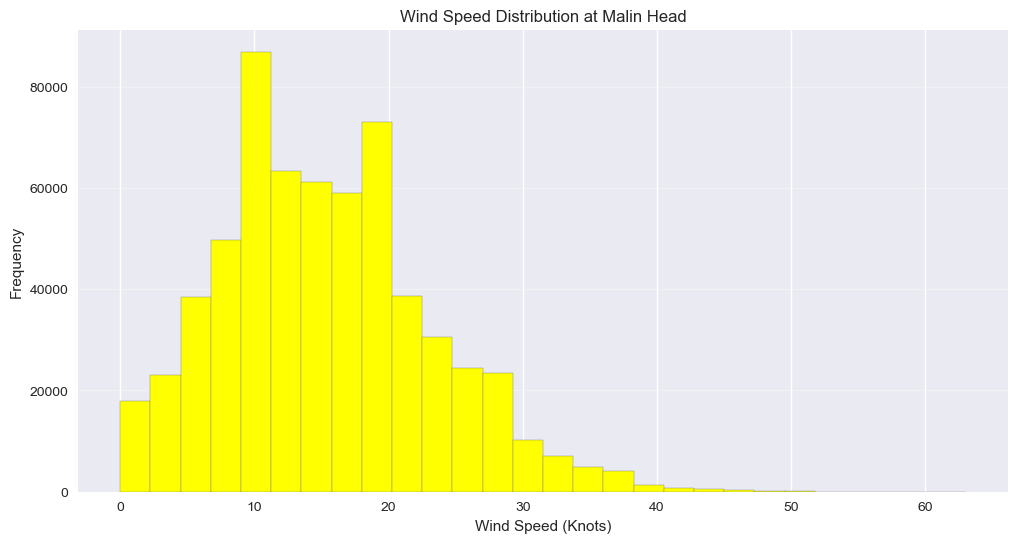

In [832]:
# Plot histogram of wind speed for Malin Head
plt.figure(figsize=(12, 6))

plt.hist(malin_df['wdsp'], bins=28, color='yellow', edgecolor='grey')
plt.title('Wind Speed Distribution at Malin Head')
plt.xlabel('Wind Speed (Knots)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

The histogram for Malin Head shows that most wind speed values are concentrated in the range of approximately 9-20 knots, with the median value of 14 knots located close to the centre of this range. The distribution displays a slight right skew, indicating that higher wind speeds occur less frequently, with a tail extending to a maximum value of 63 knots. The wide spread of values and a relatively high standard deviation reflect the exposed nature of the north-west coastal location.

### Mace Head

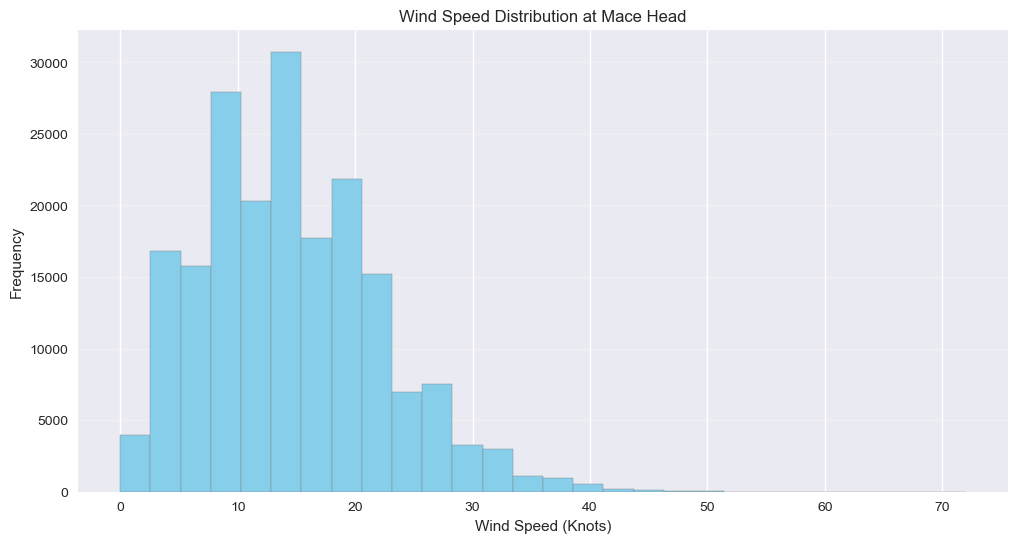

In [833]:
# Plot histogram of wind speed for Mace Head
plt.figure(figsize=(12, 6))

plt.hist(mace_df['wdsp'], bins=28, color='skyblue', edgecolor='grey')
plt.title('Wind Speed Distribution at Mace Head')
plt.xlabel('Wind Speed (Knots)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

The histogram for Mace Head shows a similar overall pattern to Malin Head, with most wind speed values falling between approximately 9 and 19 knots and a median wind speed of 14 knots. The distribution is slightly right-skewed, with occasional high wind events extending up to a maximum of 72 knots. The relatively large spread and variability reflect the exposed Atlantic coastal environment.

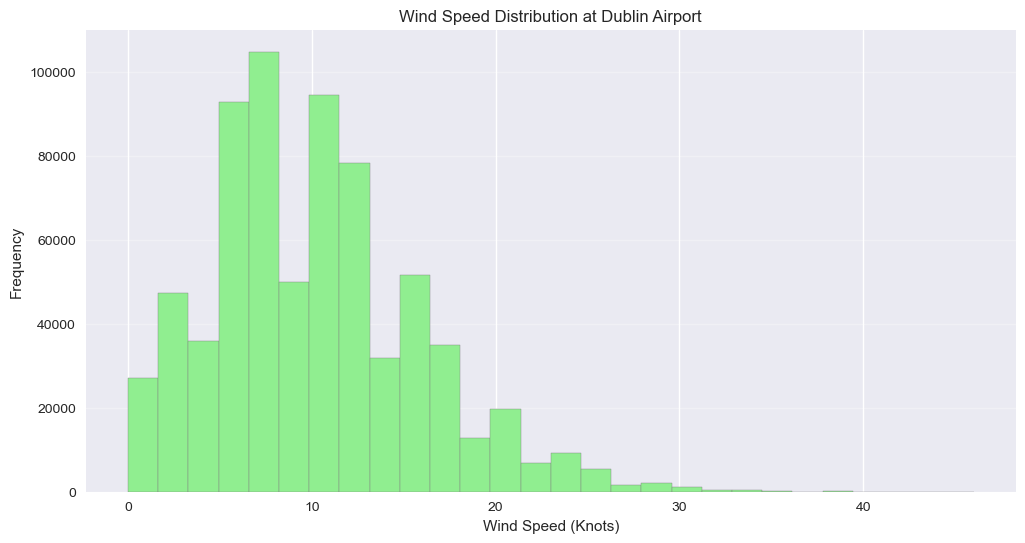

In [834]:
# Plot histogram of wind speed for Dublin Airport
plt.figure(figsize=(12, 6))

plt.hist(dublin_df['wdsp'], bins=28, color='lightgreen', edgecolor='grey')
plt.title('Wind Speed Distribution at Dublin Airport')
plt.xlabel('Wind Speed (Knots)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

The histogram for Dublin Airport differs from the coastal stations, with most wind speeds concentrated between approximately 6 and 14 knots and the median wind speed of 9 knots, which is lower than at the coastal locations.

Although the distribution also shows a slight right skew, the overall spread is narrower and the maximum recorded wind speed (46 knots) is considerably lower. This indicates less variable and weaker wind conditions, which is expected given Dublin Airport’s more sheltered inland location.


## Wind speed ranges

According to the Wikipedia page on [Wind turbine design](https://en.wikipedia.org/wiki/Wind_turbine_design?utm_source=chatgpt.com), turbines generate usable power only within specific wind speed ranges. A minimum cut-in speed of approximately 3–4 metres per second is required for operation, while turbines shut down at  speeds above the cut-out threshold of around 25 metres per second for safety reasons. 

Converted to knots using [XConvert](https://www.xconvert.com/unit-converter/metres-per-second-to-knots/?measure=speed&value=3) based on the above thresholds: 
- **Cut-in speed**: ~5.8 knots.
- **Cut-out speed**: ~48.6 knots. 

Based on these values, wind speeds at each weather station can be grouped into operational ranges: 
- **Below cut-in speed (<5.8kt)**: turbine does not operate. 
- **Operating range (>=5.8kt and <= 48.6kt)**: turbine can generate power.
- **Above cut-out speed (>48.6kt)**: turbine shuts down for safety.

Using these ranges, I can define a function that will calculate how often wind conditions at each location fall within the operational range.

In [ ]:
def wind_power_ranges(df, location):
    """Categorize wind power for a given location and return percentages."""

    # Count hours (number of rows) in each wind speed range using shape method
    below_cut_in = df[df['wdsp'] < 5.8].shape[0]
    operational_range = df[(df['wdsp'] >= 5.8) & (df['wdsp'] <= 48.6)].shape[0]
    above_cut_out = df[df['wdsp'] > 48.6].shape[0]

    total_hours = below_cut_in + operational_range + above_cut_out
    
    # Calculate percentages
    below_cut_in_pct = (below_cut_in / total_hours) * 100
    operational_pct = (operational_range / total_hours) * 100
    above_cut_out_pct = (above_cut_out / total_hours) * 100
    
    # Return results as a dictionary
    return {
        "location": location,
        "below_cut_in_pct": below_cut_in_pct,
        "operational_pct": operational_pct,
        "above_cut_out_pct": above_cut_out_pct
    }

To compare the percentage of hours within each wind speed range across stations, results from each location are stored in dictionaries and then combined into a single pandas DataFrame. Converting a list of dictionaries to a DataFrame was followed using the [Geeks For Geeks](https://www.geeksforgeeks.org/python/create-a-pandas-dataframe-from-list-of-dicts/?utm_source=chatgpt.com) explanation.

In [865]:
# Call function for each location and store results
malin_results = wind_power_ranges(malin_df, "Malin Head")
mace_results = wind_power_ranges(mace_df, "Mace Head")
dublin_results = wind_power_ranges(dublin_df, "Dublin Airport")

# Combine all results into a list
all_results = [malin_results, mace_results, dublin_results]

In [837]:
# Create a DataFrame to compare results
df_comparison = pd.DataFrame(all_results)

# Show combined results as dataframe
df_comparison

,location,below_cut_in_pct,operational_pct,above_cut_out_pct
0,Malin Head,9.391385,90.577583,0.031032
1,Mace Head,10.702958,89.269752,0.027290
2,Dublin Airport,21.721507,78.278493,0.000000


### Visualise wind speed ranges at each location

A stacked bar chart is used to compare how wind speeds at each location fall within the defined operational ranges. 

The stacked bar chart approach was informed by this [Python Charts](https://www.pythoncharts.com/matplotlib/stacked-bar-charts-labels/) guide.

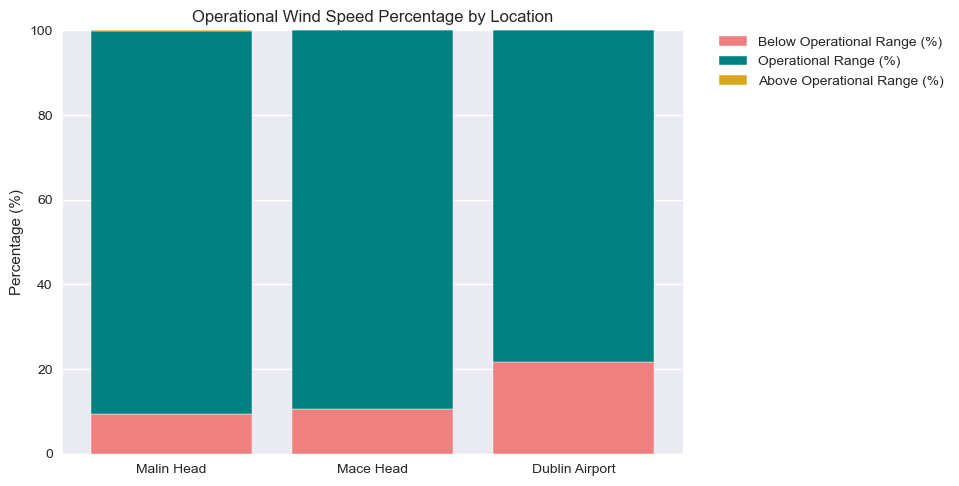

In [838]:
# Create stacked bar chart to compare operational wind power ranges across locations 
# using seaborn style (version was taken wrom the warning message on deprecated default style)
plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
ax.bar(df_comparison['location'], df_comparison['below_cut_in_pct'], label='Below Operational Range (%)', color='lightcoral')
ax.bar(df_comparison['location'], df_comparison['operational_pct'], bottom=df_comparison['below_cut_in_pct'], label='Operational Range (%)', color='teal')
ax.bar(df_comparison['location'], df_comparison['above_cut_out_pct'], bottom=df_comparison['below_cut_in_pct'] + df_comparison['operational_pct'], label='Above Operational Range (%)', color='goldenrod')
ax.set_title('Operational Wind Speed Percentage by Location')
ax.set_ylabel('Percentage (%)')
# Place legend outside the plot area
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.0
    )
plt.show()


Based on the above visualisation, the following observations are aparent: 
- Coastal locations have a higher proportion of operational wind hours
- Dublin Airport has a larger share below cut-in speed due to its shelterred inland location
- Cut-out events are rare across all stations

## Seasonal and time trends for wind power generation

Based on findings from the [CSO](https://www.cso.ie/en/releasesandpublications/ep/p-meg/meteredelectricitygenerationnovember2023/keyfindings/#:~:text=Half%2Dhourly%20Generation%20Trends%20During,MWh%20(See%20Table%201A). ) report (November 2023) on metered electricity generation, two key trends relevant to this analysis can be observed: 
1. Wind energy generation is typically highest during the winter months, although it varies throughout the year. Lower levels of wind generation were observed in May and June.
2. Peak electricity demand generally occurs from around 4:30 pm to 8:00 pm, with the highest demand typically between 5:30 pm and 6:30 pm.

Taking these trends into account, the following section examines **seasonal patterns in wind speed**, focusing on the most recent ten-year period. A subsequent section then explores **time-of-day variations** in wind availability in relation to peak electricity demand.

### Calculate monthly average wind speed at each location

To analyse seasonal trends, monthly average wind speeds are calculated for each location and combined into a single DataFrame.

In [839]:
# Calculate monthly average wind speed for each location
malin_monthly = malin_df["wdsp"].resample("M").mean()
mace_monthly = mace_df["wdsp"].resample("M").mean()
dublin_monthly = dublin_df["wdsp"].resample("M").mean()

# Combine monthly averages into one dataframe
# Set column names to location names
monthly_df = pd.DataFrame({
    "Malin Head": malin_monthly,
    "Mace Head": mace_monthly,
    "Dublin Airport": dublin_monthly
})

# Show combined monthly averages dataframe
monthly_df

,Malin Head,Mace Head,Dublin Airport
date,,,
1945-01-31,NaN,NaN,12.638441
1945-02-28,NaN,NaN,14.005952
1945-03-31,NaN,NaN,11.095430
1945-04-30,NaN,NaN,10.005556
1945-05-31,NaN,NaN,9.095430
...,...,...,...
2025-08-31,12.751344,13.763441,8.400538
2025-09-30,14.638889,17.184722,8.250000
2025-10-31,16.201613,17.491935,9.577957


### Set time period
To ensure a consistent comparison across all locations, the analysis is restricted to the most recent ten-year period. The latest timestamp in the dataset is identified using the `max()` method, and the start of the analysis period is determined by subtracting ten years using `pd.DateOffset`.

In [ ]:
# Define time window (last 10 years)
end_date = monthly_df.index.max()
start_date = end_date - pd.DateOffset(years=10)

monthly_df_10y = monthly_df.loc[start_date:end_date]

### Visualise seasonal trends 
The plot below shows monthly average wind speeds over the last ten years for each location. Date formatting on the x-axis uses functionality from the [matplotlib.dates](https://matplotlib.org/stable/api/dates_api.html) module, with major ticks indicating years and minor ticks indicating months. The approach was informed by a [Stack Overflow](https://stackoverflow.com/questions/9627686/plotting-dates-on-the-x-axis) discussion.

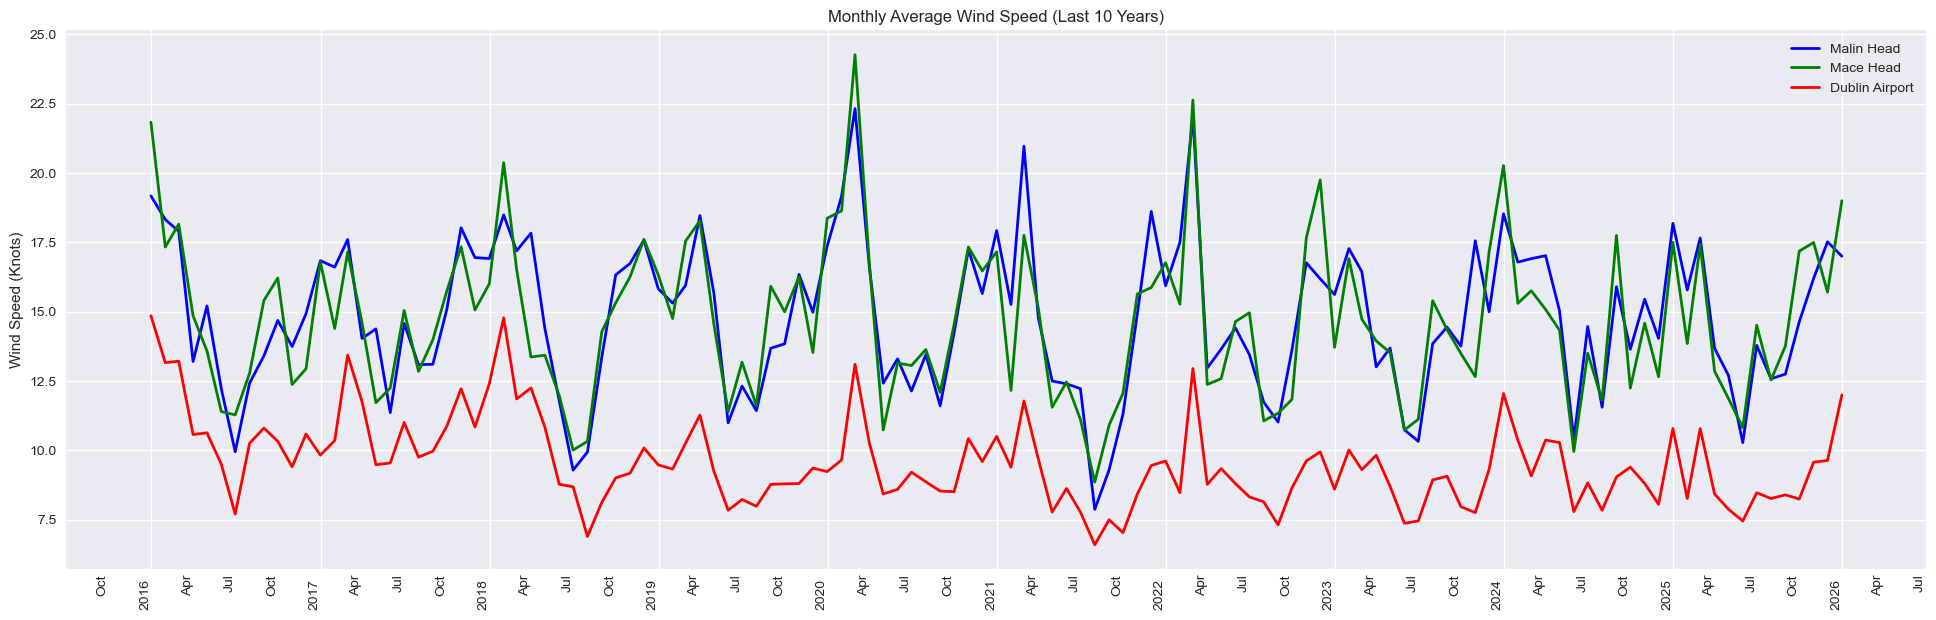

In [ ]:
fig, ax = plt.subplots(figsize=(24, 7))

# Plot monthly average wind speeds for each location
ax.plot(monthly_df_10y.index, monthly_df_10y["Malin Head"], label='Malin Head', linewidth=2, color='blue')
ax.plot(monthly_df_10y.index, monthly_df_10y["Mace Head"], label='Mace Head', linewidth=2, color='green')
ax.plot(monthly_df_10y.index, monthly_df_10y["Dublin Airport"], label='Dublin Airport', linewidth=2, color='red')

# Set titles and labels
ax.set_title('Monthly Average Wind Speed (Last 10 Years)')
ax.set_ylabel('Wind Speed (Knots)')

# X-axis formatting
# Major ticks: daily markers with Month-Day labels
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
for label in ax.get_xticklabels(which='major'):
    label.set(rotation=90, horizontalalignment='right')

# Minor ticks: hourly markers without labels
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))
for label in ax.get_xticklabels(which='minor'):
    label.set(rotation=90, horizontalalignment='right')

ax.legend()

plt.show()

The monthly average wind speed trends show a clear seasonal pattern across all three locations over the past decade. Wind speeds are generally higher during winter months and lower during summer, indicating that wind power availability is seasonally dependent.

Malin Head and Mace Head show consistently higher average wind speeds than Dublin Airport, reflecting their exposed coastal locations. Dublin Airport shows lower wind speeds, consistent with its more shelterred inland setting.

## Percentage of hours within operational wind speed range for a "typical" month of year
To better assess wind power availability, the analysis now focuses on the proportion of time during which wind speeds fall within the operational range of a wind turbine. For each location, the percentage of hourly observations within the cut-in and cut-out wind speed thresholds is calculated for each month.

In [ ]:
# Define function to calculate monthly operational percentage of wind speeds
def monthly_operational_percentage(df, cut_in=5.8, cut_out=48.6):
    """Calculate the % of hours within operational range per month"""

    # Total wind speed hours per month
    total_hours = df['wdsp'].groupby(df.index.month).count()

    # Filter only operational wind speeds
    operational_df = df[
        (df['wdsp'] >= cut_in) & (df['wdsp'] <= cut_out)
        ]

    # Count operational hours per typical month
    operational_hours = operational_df['wdsp'].groupby(operational_df.index.month).count()

    # Percentage of operational hours
    operational_pct = (operational_hours / total_hours) * 100

    return operational_pct


In [843]:
# Call function for each location and store results
malin_monthly_pct = monthly_operational_percentage(malin_df)
mace_monthly_pct = monthly_operational_percentage(mace_df)
dublin_monthly_pct = monthly_operational_percentage(dublin_df)

# Combine monthly operational percentages into one dataframe
monthly_pct_df = pd.DataFrame({
    "Malin Head": malin_monthly_pct,
    "Mace Head": mace_monthly_pct,
    "Dublin Airport": dublin_monthly_pct
})

# Show combined monthly operational percentages dataframe
monthly_pct_df

,Malin Head,Mace Head,Dublin Airport
date,,,
1,95.201613,88.789101,83.552370
2,94.617880,92.658092,83.703016
3,92.945469,89.491691,82.287933
4,88.882937,88.178852,77.657750
5,86.454764,87.964321,75.071353
6,85.579030,86.231061,73.010974
7,84.851583,86.306695,73.504912
8,85.623058,87.136139,71.905283
9,90.025430,89.814353,74.799383


### Visualise monthly wind availability by location
The bar chart below compares the monthly percentage of hours during which wind speeds are within the operational range across all three locations.

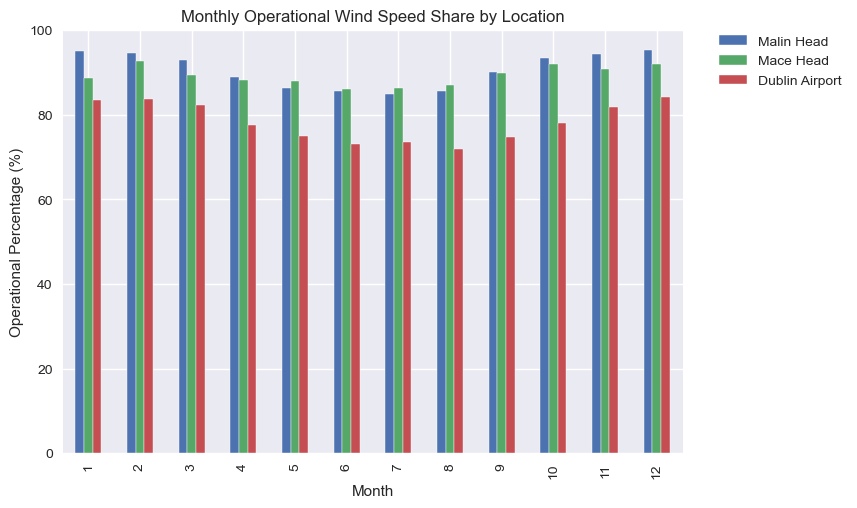

In [844]:
# Plot monthly operational wind speed percentages for each location
plt.style.use('seaborn-v0_8')  

fig, ax = plt.subplots()

monthly_pct_df.plot(kind='bar', ax=ax)
ax.set_title('Monthly Operational Wind Speed Share by Location')
ax.set_xlabel('Month')
ax.set_ylabel('Operational Percentage (%)')
ax.legend(title='Location')

# Place legend outside the plot area
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.0
    )

plt.show()

The results show that wind speeds fall within the turbine operating range for a large proportion of hours throughout the year, particularly during winter months. Coastal locations exhibit consistently higher operational availability, while Dublin Airport shows reduced suitability, reflecting its more sheltered inland location.

## Time of day analysis

To assess how wind conditions align with periods of high electricity demand (**5.30-6.30pm peak hours**), the analysis now examines the percentage of hours within the turbine operating range for each hour of the day, aggregated across the full dataset.

In [ ]:
# Define function to calculate hourly operational percentage of wind speeds
def hourly_operational_percentage(df, cut_in=5.8, cut_out=48.6):
    """Calculate the percentage of hours within the operational wind speed range
    for each hour of the day.
    """

    # Total wind speed observations per hour of day
    total_hours = df['wdsp'].groupby(df.index.hour).count()

    # Filter only operational wind speeds
    operational_df = df[
        (df['wdsp'] >= cut_in) & (df['wdsp'] <= cut_out)
        ]

    # Count operational hours per a typical hour of day
    operational_hours = operational_df['wdsp'].groupby(operational_df.index.hour).count()

    # Percentage of operational hours
    operational_hourly_pct = (operational_hours / total_hours) * 100

    return operational_hourly_pct


In [846]:
# Call function for each location and store results
malin_hourly_pct = hourly_operational_percentage(malin_df)
mace_hourly_pct = hourly_operational_percentage(mace_df)
dublin_hourly_pct = hourly_operational_percentage(dublin_df)

# Combine daily operational percentages into one dataframe
hourly_pct_df = pd.DataFrame({
    "Malin Head": malin_hourly_pct,
    "Mace Head": mace_hourly_pct,
    "Dublin Airport": dublin_hourly_pct
})

# Show combined daily operational percentages dataframe
hourly_pct_df

,Malin Head,Mace Head,Dublin Airport
date,,,
0,87.928627,86.916234,70.698697
1,88.491078,86.814137,71.205251
2,88.688906,86.900643,71.492861
3,89.022498,86.764706,71.699262
4,89.309542,86.591696,71.597753
5,89.441427,86.517548,71.851526
6,89.674166,86.441725,72.937673
7,90.019395,86.281053,75.346823
8,90.795190,86.911383,78.023279


### Visualise wind power availability during peak demand hours

For the heatmap visualisation, the following sources and approaches were used:

- Horizontal reference lines were added using the `matplotlib.pyplot.hlines` functionality, as described in the [Matplotlib documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hlines.html).
- The shaded peak-demand region was implemented based on an example from the `Matplotlib` [fill_between](https://matplotlib.org/stable/gallery/lines_bars_and_markers/fill_between_demo.html) documentation.
- Line annotations follow an approach outlined by [Geeks for Geeks](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hlines.html) for the `matplotlib.pyplot.annotate()` method.
- Parts of the plotting code were initially auto-suggested by Visual Studio Copilot and subsequently refined through experimentation.

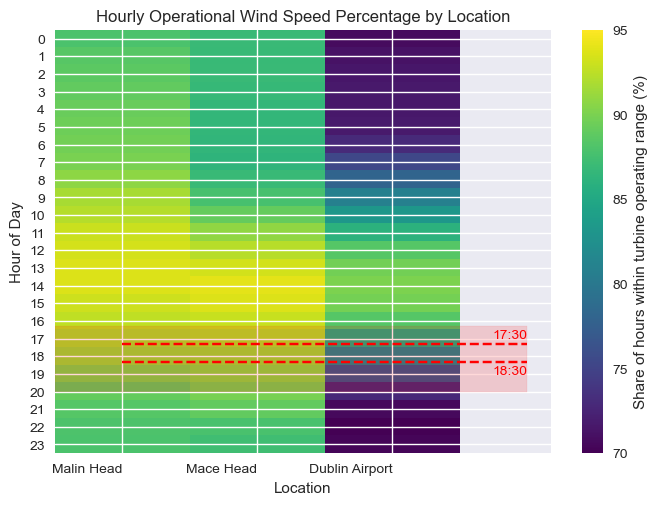

In [847]:
# Prepare data for plotting heatmap
hours = hourly_pct_df.index
locations = hourly_pct_df.columns.tolist()
data = hourly_pct_df.values

# Define peak demand period (used for shading)
y1 = 16.30
y2 = 20

# Plot heatmap of hourly operational wind speed percentages
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots()
im = ax.imshow(data, aspect='auto', cmap='viridis', vmin=70, vmax=95)

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(locations)), labels=locations,
              ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(hours)), labels=hours)

# Create colorbar to indicate percentage scale
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Share of hours within turbine operating range (%)')

# Set labels and title
ax.set_xlabel("Location")
ax.set_ylabel("Hour of Day")
ax.set_title("Hourly Operational Wind Speed Percentage by Location")

# Add horizontal lines for the highest demand hours
ax.hlines(y=17.30, xmin=0, xmax=len(locations), colors='red', linestyles='dashed')
ax.hlines(y=18.30, xmin=0, xmax=len(locations), colors='red', linestyles='dashed')

# Add annotations for the highest demand hours
ax.annotate('17:30', xy=(len(locations), 17.30), xytext=(len(locations), 17),
            color='red', ha='right')
ax.annotate('18:30', xy=(len(locations), 18.30), xytext=(len(locations), 19),
            color='red', ha='right')

# Shade the peak demand period
ax.fill_between(x=[-0.5, len(locations)], y1=y1, y2=y2, color='red', alpha=0.15)

plt.show()

The heatmap shows the share of hours during which wind speeds fall within the turbine operational range for each hour of the day. Focusing on the peak electricity demand period (approximately 17:30–18:30), the following observations can be made:

- **Malin Head** shows very high wind availability during peak demand hours, with operational wind speeds occurring in ~ **90–93%** of hours.
- **Mace Head** exhibits similarly strong performance, with operational availability of around **88–92%** during the same period.
- **Dublin Airport** shows lower but still substantial wind availability during peak demand hours, typically in the range of **75–80%**.

Overall, wind power in Ireland is generally well-aligned with daily demand peaks, particularly for exposed coastal sites.

## Long-term Trends and Future Outlook

To investigate long-term trends in wind speed over past decades, a helper function is defined to perform the following steps:
- Calculate annual average wind speeds for each location using the `pandas` [`resample`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) method.
- Apply a 5-year rolling mean to smooth short-term variability and highlight underlying trends.
- Remove any remaining missing values using the `dropna()` method.

This function allows the same data processing steps to be applied consistently across all datasets, preparing the data for visualising and comparing long-term wind speed trends.

In [ ]:
def annual_wind_trend(df, window=5):
    """ Calculate yearly mean wind speed and a rolling mean trend"""
    # Calculate annual mean wind speed
    yearly_mean = df['wdsp'].resample('Y').mean()

    # Drop any remaining missing values for accurate rolling mean calculation
    yearly_mean = yearly_mean.dropna()

    # Calculate rolling mean
    rolling_mean = yearly_mean.rolling(window=window).mean()

    return yearly_mean, rolling_mean

In [ ]:
# Call function for each location and print results
malin_yearly, malin_rolling = annual_wind_trend(malin_df)
mace_yearly, mace_rolling = annual_wind_trend(mace_df)
dublin_yearly, dublin_rolling = annual_wind_trend(dublin_df)    

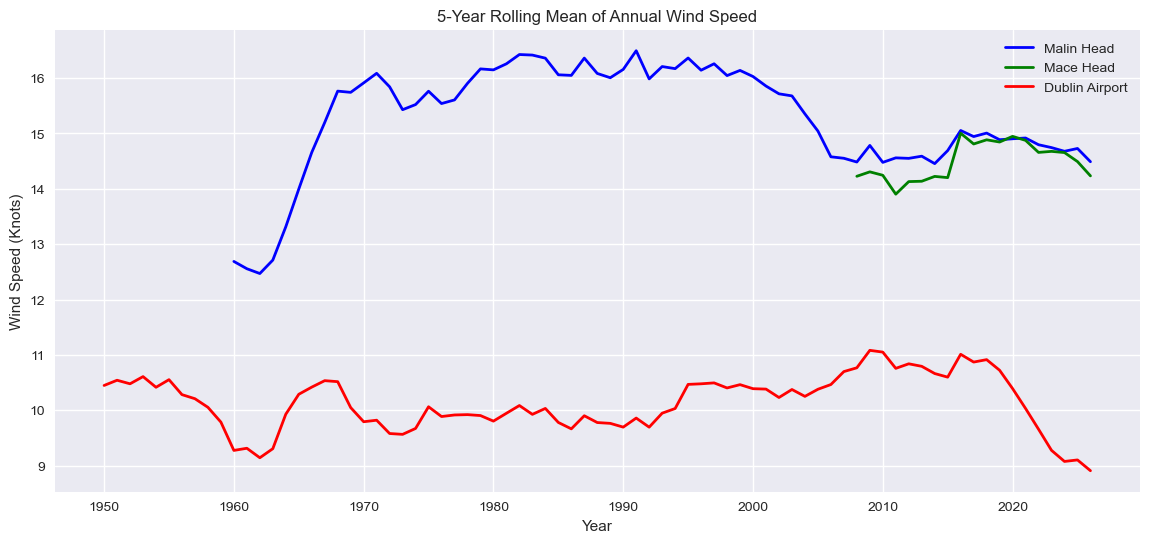

In [850]:
# Plot rolling mean trends for each location
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(malin_rolling.index, malin_rolling, label='Malin Head', linewidth=2, color='blue')
ax.plot(mace_rolling.index, mace_rolling, label='Mace Head', linewidth=2, color='green')
ax.plot(dublin_rolling.index, dublin_rolling, label='Dublin Airport', linewidth=2, color='red')

ax.set_title('5-Year Rolling Mean of Annual Wind Speed')
ax.set_ylabel('Wind Speed (Knots)')
ax.set_xlabel('Year')
ax.legend()

plt.show()


While coastal locations maintain higher wind speeds, recent decades show stable or slightly declining trends, suggesting future wind conditions may fluctuate rather than steadily increase.

## Linear Regression

To assess long-term trends in wind speeds over the historical record, a linear regression is performed for each dataset. This fits a straight line through the annual mean wind speeds, indicating whether wind conditions are increasing, decreasing, or stable over time.

A function is defined to perform a linear regression on annual mean wind speed and return three values:
- `y_pred`: the predicted wind speed for each year (used to plot the linear trend line).
- `slope`: the annual change in wind speed (knots/year).
- `intercept`: the starting wind speed (knots).
- `r2`: coefficient of determination (*R²*), which indicates how well the regression line fits the data (values closer to 1 mean a better fit).

References: 
- Linear regression is calculated using `scikit-learn` [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model.
- A [DataCamp tutorial](https://www.datacamp.com/tutorial/sklearn-linear-regression), among other resources, was helpful for understanding linear regression and its implementation in `scikit-learn`. 
- The `reshape()` method from `numpy` is used to convert the `malin_yearly.index.year` values into the required array format, as explained in this [Study Trigger](https://www.studytrigger.com/article/regression-in-machine-learning/?utm_source=chatgpt.com) article on regression in machine learning.
- To evaluate the fit of the regression lines, the coefficient of determination (*R²*) is calculated, following guidance from this [Geeks for Geeks](https://www.geeksforgeeks.org/machine-learning/python-coefficient-of-determination-r2-score/) tutorial.

In [ ]:
def linear_trend(yearly_mean):
    """Perform linear trend analysis on annual mean wind speed data.
    Returns predicted values, slope, intercept, and R-squared."""
    
    # Prepare data for linear regression
    X = np.array(yearly_mean.index.year).reshape(-1, 1)
    y = yearly_mean.values

    # Create and fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Predict values using the model
    y_pred = model.predict(X)

    # Extract slope and intercept
    slope = model.coef_[0] # Ensure slope is a scalar value for ease of formatting
    intercept = model.intercept_

    # Calculate R-squared value
    r2 = r2_score(y, y_pred)

    return y_pred, slope, intercept, r2

In [861]:
# Call function for each location
malin_y, malin_slope, malin_intercept, malin_r2 = linear_trend(malin_yearly)
mace_y, mace_slope, mace_intercept, mace_r2 = linear_trend(mace_yearly)
dublin_y, dublin_slope, dublin_intercept, dublin_r2 = linear_trend(dublin_yearly)

# List to store results (NEW variable)
trend_results = []

# Append results for each location
trend_results.append({
    "Location": "Malin Head",
    "Slope (knots/year)": malin_slope,
    "Intercept": malin_intercept
})

trend_results.append({
    "Location": "Mace Head",
    "Slope (knots/year)": mace_slope,
    "Intercept": mace_intercept
})

trend_results.append({
    "Location": "Dublin Airport",
    "Slope (knots/year)": dublin_slope,
    "Intercept": dublin_intercept
})

# Create DataFrame to display trend results
trend_df = pd.DataFrame(trend_results)
trend_df

,Location,Slope (knots/year),Intercept
0,Malin Head,0.003787,7.660800
1,Mace Head,0.020569,-26.960534
2,Dublin Airport,0.000454,9.212258


From these results, a slight positive trend in annual mean wind speeds is observed at all locations. Mace Head shows the largest increase, at ~ 0.02 knots per year, while Dublin Airport exhibits a much smaller change of around 0.0005 knots per year. Over a decade, these trends translate to modest changes of roughly 0.2 knots for Mace Head and 0.005 knots for Dublin Airport, indicating that long-term changes in wind speed are small relative to year-to-year variability.

### Visualise linear trends

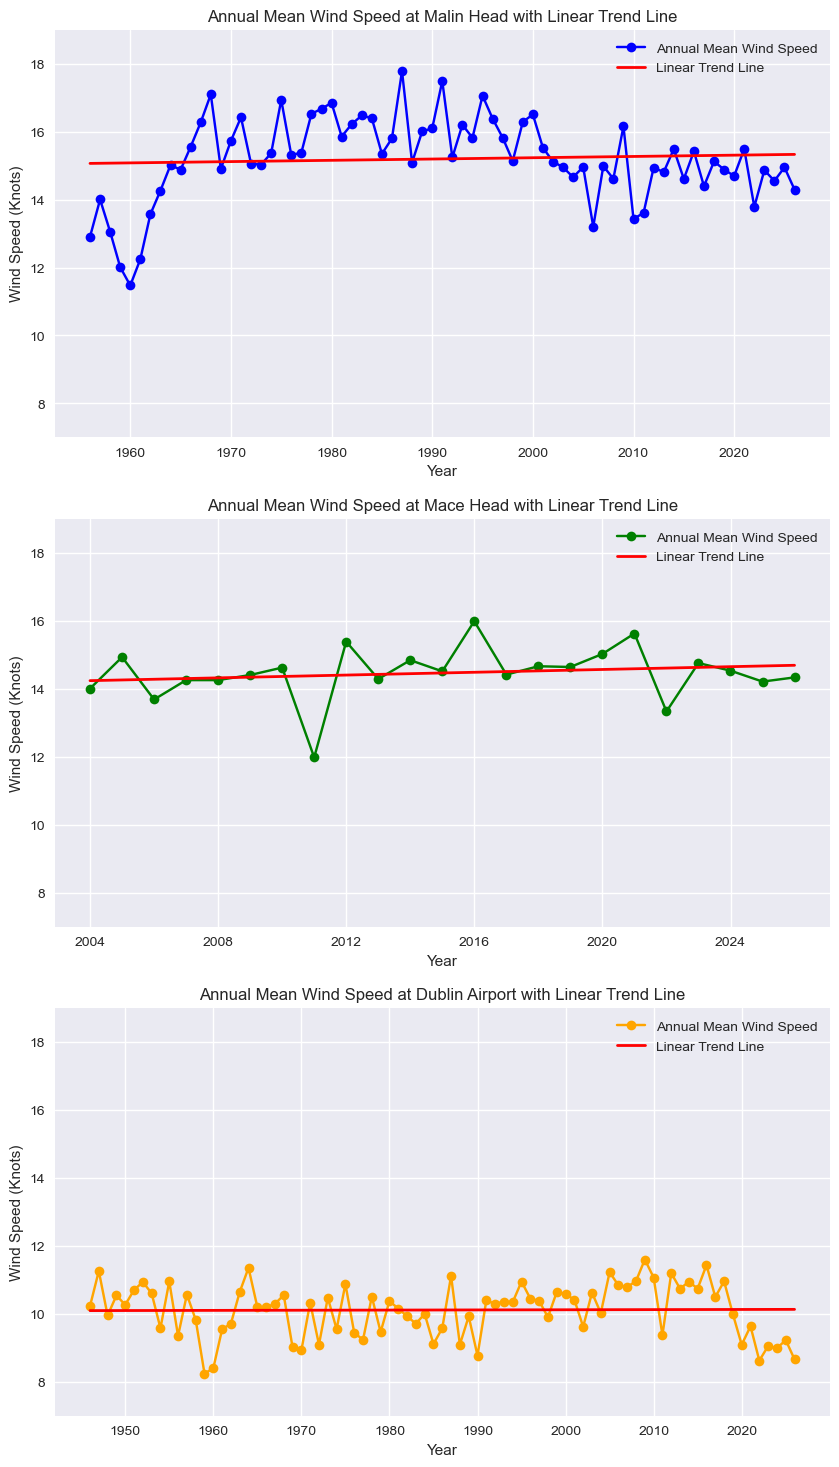

In [ ]:
# Plot annual mean wind speeds with linear trend lines for each location
fig, ax = plt.subplots(3, 1, figsize=(10, 18))

ax[0].plot(malin_yearly.index, malin_yearly, label='Annual Mean Wind Speed', marker='o', linestyle='-', color ='blue')
ax[0].plot(malin_yearly.index, malin_y, label='Linear Trend Line', color='red', linewidth=2)
ax[0].set_title('Annual Mean Wind Speed at Malin Head with Linear Trend Line')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Wind Speed (Knots)')
ax[0].set_ylim(7,19)
ax[0].legend()

ax[1].plot(mace_yearly.index, mace_yearly, label='Annual Mean Wind Speed', marker='o', linestyle='-', color ='green')
ax[1].plot(mace_yearly.index, mace_y, label='Linear Trend Line', color='red', linewidth=2)
ax[1].set_title('Annual Mean Wind Speed at Mace Head with Linear Trend Line')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Wind Speed (Knots)')
ax[1].set_ylim(7,19)
ax[1].legend()

ax[2].plot(dublin_yearly.index, dublin_yearly, label='Annual Mean Wind Speed', marker='o', linestyle='-', color ='orange')
ax[2].plot(dublin_yearly.index, dublin_y, label='Linear Trend Line', color='red', linewidth=2)
ax[2].set_title('Annual Mean Wind Speed at Dublin Airport with Linear Trend Line')
ax[2].set_xlabel('Year')
ax[2].set_ylabel('Wind Speed (Knots)')
ax[2].set_ylim(7,19)
ax[2].legend()

plt.show()  

In [864]:
# Show coefficients of determination (R squared) for each location
print(f"Malin Head R²: {malin_r2:.4f}")
print(f"Mace Head R²: {mace_r2:.4f}")
print(f"Dublin Airport R²: {dublin_r2:.4f}")

Malin Head R²: 0.0039
Mace Head R²: 0.0309
Dublin Airport R²: 0.0002


### Linear Regression and Coefficient of Determination Interpretation

The fitted linear regression lines show small positive trends in annual mean wind speeds at all locations. However, the very low R² values indicate that these lines explain almost none of the year-to-year variation. This means that while there is a slight upward trend, annual wind speeds fluctuate widely, and long-term conditions can be considered broadly stable.

## End